# 05 — Standard RAG End-to-End

**Experiment T024.** Oracle (`02_oracle_experiment.ipynb`) fed the model gold evidence directly, bypassing retrieval - it measures the model's *reasoning* ceiling. The nine rounds of retrieval experiments (`04_retrieval_experiments.ipynb`) measure Evidence Recall@K/Precision/MRR - character-span overlap with ContractNLI's annotated spans.

Neither answers the question that actually matters for the product: **does the chunk our retriever hands the classifier actually contain everything needed to classify correctly?** A small sentence-level chunk (avg 44.6 tokens - the winning method from round 2) can technically "overlap" a gold span and score as an Evidence Recall hit, while still missing the surrounding context (an exception clause, a cross-reference) that changes the correct answer.

This notebook runs the *real* pipeline end-to-end - `Retriever.query_rerank_and_boost` (sentence chunking, retrieve-20, rerank with L-12, top-7, rule-boosted via RRF) into `pipeline/classifier.py` and Gemini - on the identical 150-case stratified sample used for Oracle (seed=42), so the two are directly comparable. The gap between them is exactly what retrieval imperfection costs in real classification terms.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from pipeline.viz_style import CATEGORICAL_SLOTS, apply_style, style_axes, savefig_kwargs
from evaluation.harness import EvaluationHarness

apply_style()

harness = EvaluationHarness()
oracle = harness.load_results("runs/run_B04_oracle_google_gemini-2.5-flash-lite.jsonl")[0]
rag = harness.load_results("runs/run_T024_rag.jsonl")[0]

print(f"Oracle: model={oracle.config.model}, {len(oracle.predictions)} predictions")
print(f"RAG:    model={rag.config.model}, {len(rag.predictions)} predictions (same seed=42 sample)")

Oracle: model=google/gemini-2.5-flash-lite, 150 predictions
RAG:    model=google/gemini-2.5-flash-lite, 150 predictions (same seed=42 sample)


## Oracle vs RAG - the real cost of imperfect retrieval

In [2]:
runs = {"Oracle (gold evidence)": oracle, "RAG (real retrieval)": rag}
RUN_COLOR = {name: CATEGORICAL_SLOTS[i] for i, name in enumerate(runs)}

rows = []
for name, r in runs.items():
    m = r.metrics
    rows.append({
        "run": name,
        "accuracy": m.accuracy,
        "macro_f1": m.macro_f1,
        "risk_sensitive_recall": m.risk_sensitive_recall,
        "joint_correctness": m.joint_label_evidence_correctness,
        "cost_usd": m.total_cost_usd,
        "p50_latency_ms": m.p50_latency_ms,
    })
df = pd.DataFrame(rows).set_index("run")
df

,accuracy,macro_f1,risk_sensitive_recall,joint_correctness,cost_usd,p50_latency_ms
run,,,,,,
Oracle (gold evidence),0.953333,0.948337,1.000000,0.953333,0.012512,961.753333
RAG (real retrieval),0.860000,0.842165,0.830211,0.813333,0.000000,0.000000


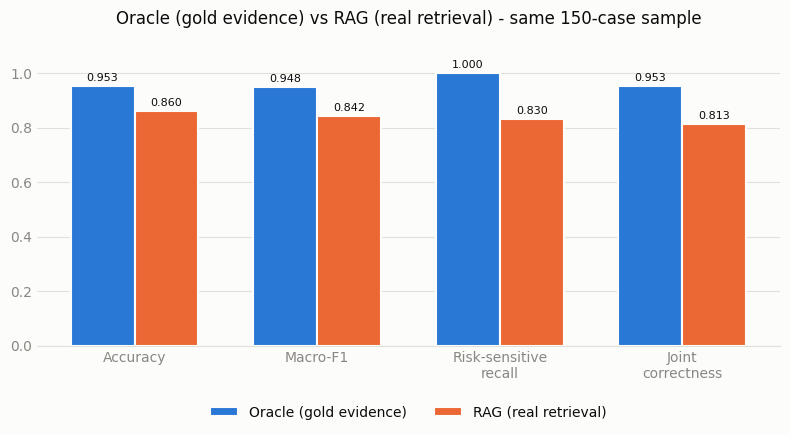

In [3]:
quality_metrics = ["accuracy", "macro_f1", "risk_sensitive_recall", "joint_correctness"]
x = range(len(quality_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (name, r) in enumerate(runs.items()):
    m = r.metrics
    values = [m.accuracy, m.macro_f1, m.risk_sensitive_recall, m.joint_label_evidence_correctness]
    bars = ax.bar([xi + i * width for xi in x], values, width,
                  label=name, color=RUN_COLOR[name], edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)

ax.set_xticks([xi + width / 2 for xi in x])
ax.set_xticklabels(["Accuracy", "Macro-F1", "Risk-sensitive\nrecall", "Joint\ncorrectness"])
ax.set_ylim(0, 1.15)
ax.set_title("Oracle (gold evidence) vs RAG (real retrieval) - same 150-case sample")
style_axes(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("results/comparisons/rag_vs_oracle.png", **savefig_kwargs())
plt.show()

## Finding: a real 9.3-point gap, not a proxy number

RAG accuracy (86.0%) sits well below Oracle's ceiling (95.3%) - a real cost of retrieval imperfection, measured on identical cases with identical prompting, not inferred from Evidence Recall@K. Joint label+evidence correctness (0.813) confirms this isn't just a labeling quirk: the combination of "right label AND right evidence" also drops meaningfully below Oracle.

This is the answer to "does the retrieved chunk actually contain what's needed for classification" - **mostly, but not always**: retrieval finds sufficient context in ~86% of cases, and falls short in the other ~14%. That's worse than the ~80% Evidence Recall@K number from the retrieval-only rounds might suggest is "safe," because recall misses and classification errors don't line up one-to-one - some genuinely find the evidence but still enough surrounding noise causes a wrong read.

## What's actually going wrong - error breakdown

In [4]:
import json
from collections import Counter

from scripts.run_oracle_experiment import SEED, stratified_sample
from pipeline.config import settings
from pipeline.parser import parse_contractnli_file

dataset = parse_contractnli_file(settings.data_path / "dev.json")
sample = stratified_sample(dataset, 150, SEED)
gold_by_key = {(doc.doc_id, ann.hypothesis_id): ann.label for doc, ann in sample}

error_types = Counter()
for pred in rag.predictions:
    gold_label = gold_by_key[(pred.doc_id, pred.hypothesis_id)]
    if pred.predicted_label.value != gold_label:
        error_types[f"{gold_label} -> {pred.predicted_label.value}"] += 1

error_df = pd.DataFrame(sorted(error_types.items(), key=lambda kv: -kv[1]), columns=["error", "count"]).set_index("error")
error_df

,count
error,
NotMentioned -> Entailment,9
Entailment -> NotMentioned,6
NotMentioned -> Contradiction,3
Contradiction -> NotMentioned,1
Contradiction -> Entailment,1
Entailment -> Contradiction,1


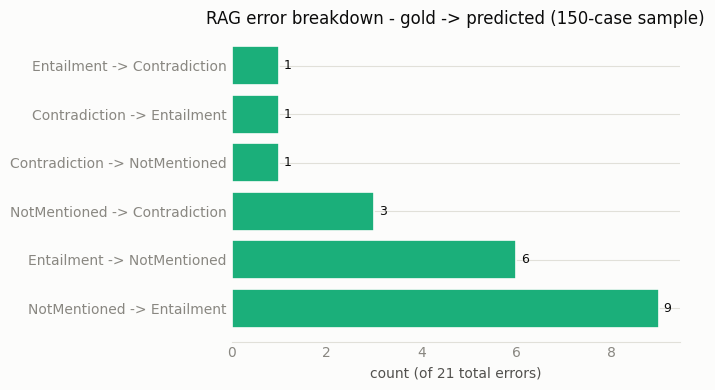

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(error_df.index, error_df["count"], color=CATEGORICAL_SLOTS[2], edgecolor="#fcfcfb", linewidth=1.2, zorder=3)
for i, v in enumerate(error_df["count"]):
    ax.text(v + 0.1, i, str(v), va="center", fontsize=9)
ax.set_xlabel("count (of 21 total errors)")
ax.set_title("RAG error breakdown - gold -> predicted (150-case sample)")
style_axes(ax)
plt.tight_layout()
plt.savefig("results/comparisons/rag_error_breakdown.png", **savefig_kwargs())
plt.show()

## Two concrete, addressable failure modes

1. **NotMentioned falsely predicted as Entailment/Contradiction (12/21 errors, 57%).** Retrieval surfaces a superficially-relevant chunk for a topic that's genuinely absent from the document, and the model - seeing only that chunk, not the whole document - can't rule it out with confidence.
2. **Entailment missed as NotMentioned (6/21 errors, 29%).** Real evidence existed in the document but wasn't in the retrieved top-7 - consistent with the measured ~20% recall miss rate from the retrieval rounds.

Failure mode #1 looks like a prompt calibration problem, not strictly a retrieval or model-capability problem - Oracle already proved the model reasons well given clean evidence. Before moving to confidence/abstention (T026), it's worth checking whether a more explicit prompt fixes it directly.

## T018: does prompt tuning fix failure mode #1?

Three variants tested against the v1 baseline above, on the identical 150-case sample and identical retrieved context (only the prompt differs):
- **v2 (explicit-conservative):** adds an instruction to default to NotMentioned unless the excerpt clearly and directly addresses the requirement, warning against inferring from shared vocabulary/topic overlap.
- **v3 (few-shot):** the same instruction, demonstrated via 3 worked examples instead of stated as a rule (one showing a topically-related-but-irrelevant excerpt correctly labeled NotMentioned).
- **v4 (forced grounding field):** requires the model to answer an explicit `addressed_directly: true/false` field before choosing a label, with a hard rule that `false` forces `NotMentioned`.

In [6]:
prompt_runs = {
    "v1 (baseline)": rag,
    "v2 (explicit-conservative)": harness.load_results("runs/run_T018_prompt_v2.jsonl")[0],
    "v3 (few-shot)": harness.load_results("runs/run_T018_prompt_v3.jsonl")[0],
    "v4 (forced grounding field)": harness.load_results("runs/run_T018_prompt_v4.jsonl")[0],
}
PROMPT_COLOR = {name: CATEGORICAL_SLOTS[i] for i, name in enumerate(prompt_runs)}

prompt_rows = []
for name, r in prompt_runs.items():
    m = r.metrics
    contradiction_recall = m.per_class.get("Contradiction", {}).get("recall", float("nan"))
    prompt_rows.append({
        "prompt": name,
        "accuracy": m.accuracy,
        "macro_f1": m.macro_f1,
        "risk_sensitive_recall": m.risk_sensitive_recall,
        "contradiction_recall": contradiction_recall,
        "cost_usd": m.total_cost_usd,
    })
prompt_df = pd.DataFrame(prompt_rows).set_index("prompt")
prompt_df

,accuracy,macro_f1,risk_sensitive_recall,contradiction_recall,cost_usd
prompt,,,,,
v1 (baseline),0.860000,0.842165,0.830211,0.857143,0.000000
v2 (explicit-conservative),0.880000,0.857778,0.854801,0.857143,0.021606
v3 (few-shot),0.846667,0.802548,0.731265,0.642857,0.025284
v4 (forced grounding field),0.846667,0.696063,0.566159,0.214286,0.022264


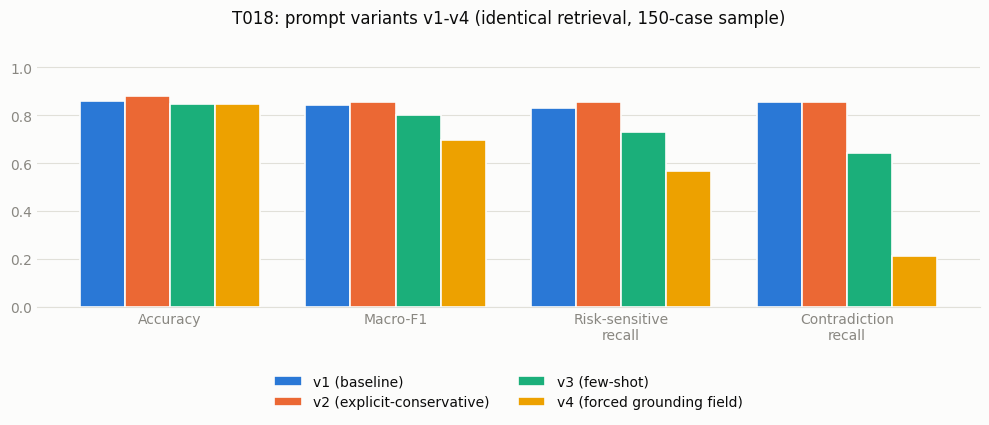

In [7]:
prompt_metrics = ["accuracy", "macro_f1", "risk_sensitive_recall", "contradiction_recall"]
x = range(len(prompt_metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, (name, r) in enumerate(prompt_runs.items()):
    m = r.metrics
    cr = m.per_class.get("Contradiction", {}).get("recall", float("nan"))
    values = [m.accuracy, m.macro_f1, m.risk_sensitive_recall, cr]
    ax.bar([xi + i * width for xi in x], values, width,
           label=name, color=PROMPT_COLOR[name], edgecolor="#fcfcfb", linewidth=1.2, zorder=3)

ax.set_xticks([xi + 1.5 * width for xi in x])
ax.set_xticklabels(["Accuracy", "Macro-F1", "Risk-sensitive\nrecall", "Contradiction\nrecall"])
ax.set_ylim(0, 1.15)
ax.set_title("T018: prompt variants v1-v4 (identical retrieval, 150-case sample)")
style_axes(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("results/comparisons/prompt_tuning_comparison.png", **savefig_kwargs())
plt.show()

## T018 finding

**v2 is the only variant that improved on v1**: accuracy 86.0%→88.0%, macro-F1 0.842→0.858, risk-sensitive recall 0.830→0.855, with no regression on any metric - a plain, clearly stated instruction, no examples and no forced decision structure.

**v3 and v4 both made things worse, and specifically on Contradiction recall** - the label with the fewest examples in every sample so far (14/150 at this stratification). v3's few-shot demonstration overcorrected the model toward "default NotMentioned" (Contradiction recall 85.7%→64.3%). v4's forced `addressed_directly` gate overcorrected far more severely (85.7%→**21.4%**) - contradictions are frequently established via a narrow carve-out/exception clause that reads, on its own, like it's only tangentially related; the model judged many of these as not "directly addressing" the hypothesis and got forced into a wrong NotMentioned by the rule.

Two independent data points now show the same shape: **engineering the prompt's decision structure (examples, forced gates) is riskier than a single clear instruction**, and the risk concentrates on the label with the least data to generalize from.

## Decision

**Adopted `prompts/classify_v2.txt` as the default** (`pipeline/classifier.py`'s `classify()` default `prompt_version`). v3 and v4 rejected. `ClassificationResult` keeps the `addressed_directly` field for forward compatibility (always `None` under v1-v3) but v4's prompt is not used in production.

**Proceed to Phase 8 (confidence/abstention, T026).** RAG at v2 now scores 88.0% accuracy - the 9.3pt gap from Oracle (95.3%) narrows to ~7.3pt, and the remaining errors are still concentrated in the same two named failure modes rather than being diffuse, which is exactly what confidence/abstention (catching over-confident false positives) and the selective agent (catching under-confident misses) are built to address.

**Revisit if:** confidence/abstention or the agent surface a *new* under-confidence problem on real Entailment/Contradiction cases now that the prompt pushes toward NotMentioned by design. Full ADR in `CLAUDE.md`'s Decisions Log.